<a href="https://colab.research.google.com/github/giumont/overlap_resolver/blob/main/notebooks/DNN_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORT FILE DATI DA GOOGLE

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# IMPORT GITHUB REPO: flavour_tag_ml (repo "flavour_tagging")

from google.colab import userdata
import os
import sys

token = userdata.get("GITHUB_TOKEN")

REPO_PATH_FLAVOUR_TAG_ML = "/content/flavour_tagging"

if not os.path.exists(REPO_PATH_FLAVOUR_TAG_ML):
    !git clone https://{token}@github.com/giumont/flavour_tagging.git {REPO_PATH_FLAVOUR_TAG_ML}
else:
    !git -C {REPO_PATH_FLAVOUR_TAG_ML} pull --rebase

# The importable package lives under <repo>/src/flavour_tag_ml, so we add
# <repo>/src (not the repo root) to sys.path and import it as a top-level
# package: "import flavour_tag_ml".
SRC_PATH_FLAVOUR_TAG_ML = os.path.join(REPO_PATH_FLAVOUR_TAG_ML, "src")
if SRC_PATH_FLAVOUR_TAG_ML not in sys.path:
    sys.path.append(SRC_PATH_FLAVOUR_TAG_ML)

import flavour_tag_ml


Cloning into '/content/flavour_tagging'...
remote: Enumerating objects: 950, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 950 (delta 67), reused 84 (delta 35), pack-reused 815 (from 2)
Receiving objects: 100% (950/950), 156.50 MiB | 32.75 MiB/s, done.
Resolving deltas: 100% (502/502), done.


In [16]:
# IMPORT GITHUB REPO: overlap_resolver
#
# Contains, under "src/": obj_3_1.py, overlap_kinematics.py,
# truth_vs_reco_params.py and overlap_pairs_dataset_builder.py (this
# notebook's main orchestrator).

token_overlap = userdata.get("GITHUB_TOKEN_OVERLAP_RESOLVER")

REPO_PATH_OVERLAP_RESOLVER = "/content/overlap_resolver"

if not os.path.exists(REPO_PATH_OVERLAP_RESOLVER):
    !git clone https://{token_overlap}@github.com/giumont/overlap_resolver.git {REPO_PATH_OVERLAP_RESOLVER}
else:
    !git -C {REPO_PATH_OVERLAP_RESOLVER} pull --rebase

# Unlike flavour_tag_ml, the modules under overlap_resolver/src are FLAT:
# they import each other directly (e.g. overlap_kinematics.py does
# "from obj_3_1 import ..." and "from truth_vs_reco_params import ...",
# NOT "from src.obj_3_1 import ..."). To keep them working unmodified, we
# append the "src" folder ITSELF to sys.path (not the repo root), and
# import them below as flat top-level modules.
SRC_PATH_OVERLAP_RESOLVER = os.path.join(REPO_PATH_OVERLAP_RESOLVER, "src")
if SRC_PATH_OVERLAP_RESOLVER not in sys.path:
    sys.path.append(SRC_PATH_OVERLAP_RESOLVER)


Cloning into '/content/overlap_resolver'...
remote: Enumerating objects: 1001, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 1001 (delta 78), reused 159 (delta 48), pack-reused 804 (from 1)
Receiving objects: 100% (1001/1001), 719.80 MiB | 30.75 MiB/s, done.
Resolving deltas: 100% (368/368), done.
Updating files: 100% (616/616), done.


In [3]:
# IMPORT FILE PROGETTO DA GITHUB

from flavour_tag_ml.data import JetDataset, build_jet_features, extract_balanced_subset, compute_feature_stats
from flavour_tag_ml.merge_datasets import merge_checkpoint_chunks, check_checkpoint_progress

from flavour_tag_ml.models import create_model
from flavour_tag_ml.training import CategoricalFocalLoss, run_epoch, get_predictions, train_model, create_dataloaders

from flavour_tag_ml.utils import set_seed, load_mmap, save_run_outputs, build_metrics_report, run_evaluation_suite

In [4]:
# To reload imported files if they have been modified during runtime

import importlib
import flavour_tag_ml.data
import flavour_tag_ml.models
import flavour_tag_ml.training
import flavour_tag_ml.graphics
import flavour_tag_ml.utils

importlib.reload(flavour_tag_ml.data)
importlib.reload(flavour_tag_ml.merge_datasets)
importlib.reload(flavour_tag_ml.models)
importlib.reload(flavour_tag_ml.training)
importlib.reload(flavour_tag_ml.graphics)
importlib.reload(flavour_tag_ml.utils)

#from flavour_tag_ml.utils import build_jet_features

<module 'flavour_tag_ml.utils' from '/content/flavour_tagging/src/flavour_tag_ml/utils.py'>

In [5]:
# IMPORT PYTHON LIBRARIES

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# sposta file in memoria locale colab
#!cp /content/drive/MyDrive/obj_2/*.h5 /content/

In [6]:
#################################################################
# GLOBAL PARAMS
#################################################################

# FILES
#DATASETS_DIR = '/content/' #gpu
INPUT_DIR = "/content/drive/MyDrive/overlap_resolver/datas/np_arrays/HH_bbtt" #cpu
#INPUT_DIR = "/content/drive/MyDrive/overlap_resolver/datas/np_arrays/bkg_tt" #cpu


TRAINSET_X_NAME = 'X_train_normalized.npy'
TRAINSET_Y_NAME = 'y_train_normalized.npy'

VALSET_X_NAME   = 'X_val_normalized.npy'
VALSET_Y_NAME   = 'y_val_normalized.npy'

TESTSET_X_NAME  = 'X_test_normalized.npy'
TESTSET_Y_NAME = 'y_test_normalized.npy'

#CHECK_LOAD_FILENAME = 'train_normalization_params.npz' # file with weights and feature_names (available for full, not reduced dataset)
CHECK_LOAD_FILENAME = "pair_feature_names.npz"

# DATASET
N_TRAIN = None
N_VAL   = None
N_TEST  = None

# OUTPUT_DIR = '/content/drive/MyDrive/flavour_tagging/obj_2/datas/np_arrays/MC23G_dataset'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_DIR = None

SUB_TRAINSET_NAME = None
SUB_VALSET_NAME = None
SUB_TESTSET_NAME = None

# PROBLEM DEFINITION
NUM_CLASSES = 4 # FF=0, FT=1, TF=2, TT=3
CLASS_NAMES = ["FF", "FT", "TF", "TT"]  # ordine coerente con le label 0,1,2,3

TASK = "multiclass" if NUM_CLASSES > 2 else "binary"

# RETE
HIDDEN_DIMS = (32, 16)

ACTIV_FUNC = nn.ReLU()
NORM_LAYER = nn.LayerNorm

DROPOUT = 0.1 # percentuale neuroni disattivati randomicamente: riduce overfitting

MODEL_CONFIG = {
    "name": "MLPMultiTagger",
    "hidden_dims": HIDDEN_DIMS,
    "num_classes": NUM_CLASSES,
    "norm_layer": NORM_LAYER,
    "dropout": DROPOUT,
}

# TRAINING
BEST_MODEL_FOR_VALIDATION = True # False: salva a prescindere i weights dell'ultima epoca; True: previene overfitting
BEST_MODEL_METRIC = "ap_macro" # "mean" / "median" / "f1_macro" / "ap_macro": quale metrica su val viene considerata per aggiornare best_model

SAMPLING_STRATEGY = "none" # "none" / "oversample" / "undersample"

CRITERION = CategoricalFocalLoss()
WEIGHTED_LOSS = True

LR = 1e-3 # learning rate ottimizzatore
WEIGHT_DECAY = 1e-4  # regolarizzazione L2 nell'ottimizzatore

OPTIMIZER_CONFIG = {
    "name": "AdamW",
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
}

SCHEDULER_FACTOR = 0.7
SCHEDULER_PATIENCE = 5

SCHEDULER_CONFIG = {
    "name": "ReduceLROnPlateau",
    "factor": SCHEDULER_FACTOR,
    "patience": SCHEDULER_PATIENCE,
    "mode": "max"   # "max" must be used with "f1_macro" / "ap_macro" metrics
}

BATCH_SIZE = 2048
MAX_EPOCHS = 50
EARLY_STOP_PATIENCE = 10

MIN_DELTA_VAL_LOSS = 1e-4 # soglia minima miglioramento loss su valset tra due epoche

# Suffisso comune per i nomi dei file salvati (architettura + training)
RUN_TAG = (
    f"{len(HIDDEN_DIMS)}layers_"
    f"{'_'.join(str(h) for h in HIDDEN_DIMS)}_"
    f"dropout{DROPOUT}_{NORM_LAYER.__name__}_batch{BATCH_SIZE}"
    f"_lr{LR}_wd{WEIGHT_DECAY}"
    f"_best_on_{BEST_MODEL_METRIC}"
    f"_criterion_{CRITERION}"
    f"_weight_loss_{WEIGHTED_LOSS}"
    f"_sampling_strategy_{SAMPLING_STRATEGY}"
)

# Store weights: nome/percorso generati automaticamente da RUN_TAG,
MODEL_DIR = '/content/drive/MyDrive/overlap_resolver/models/HH_bbtt_dataset'
#MODEL_DIR = '/content/drive/MyDrive/overlap_resolver/models/bkg_tt_dataset'

os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_NAME = f"best_model_{RUN_TAG}.pt"
MODEL_PATH = os.path.join(MODEL_DIR, MODEL_NAME)

CHECKPOINT_NAME = f"checkpoint_{RUN_TAG}.pt"
CHECKPOINT_PATH = os.path.join(MODEL_DIR, CHECKPOINT_NAME)

# GRAPHICS
GRAPHICS_DIR = "/content/drive/MyDrive/overlap_resolver/graphics/model_eval/HH_bbtt_dataset"
#GRAPHICS_DIR = "/content/drive/MyDrive/overlap_resolver/graphics/model_eval/bkg_tt_dataset"
os.makedirs(GRAPHICS_DIR, exist_ok=True)

# GITHUB
GIT_OUTPUT_DIR = "DNN/HH_bbtt_dataset"
#GIT_OUTPUT_DIR = "DNN/bkg_tt_dataset"

# OTHER
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
# SET GLOBAL SEED
set_seed(RANDOM_SEED)

In [ ]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
Device: cuda
GPU: Tesla T4


In [8]:
# LOADING INPUT

X_train = load_mmap(INPUT_DIR, TRAINSET_X_NAME)
y_train = load_mmap(INPUT_DIR, TRAINSET_Y_NAME)

X_val = load_mmap(INPUT_DIR, VALSET_X_NAME)
y_val = load_mmap(INPUT_DIR, VALSET_Y_NAME)

X_test = load_mmap(INPUT_DIR, TESTSET_X_NAME)
y_test = load_mmap(INPUT_DIR, TESTSET_Y_NAME)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(377567, 21) (377567,)
(80923, 21) (80923,)
(81083, 21) (81083,)


In [9]:
# WEIGHTS PER LOSS PESATA - GESTIONE IMBALANCE CLASSI

if WEIGHTED_LOSS:
  # Class weighting per gestire l'imbalance (FF 10.1%, FT 73.1%, TF 16.1%, TT 0.65%).
  # Calcolati SOLO sul train set (mai su val/test).
  train_class_counts = torch.bincount(torch.as_tensor(y_train, dtype=torch.long), minlength=NUM_CLASSES).float()
  CLASS_WEIGHTS = train_class_counts.sum() / (NUM_CLASSES * train_class_counts)
  CLASS_WEIGHTS = CLASS_WEIGHTS.to(DEVICE)

  if isinstance(CRITERION, nn.CrossEntropyLoss):
    CRITERION.weight=CLASS_WEIGHTS
  elif isinstance(CRITERION, CategoricalFocalLoss):
    CRITERION.alpha=CLASS_WEIGHTS
  else:
    raise ValueError("The specified criterion is not available.")

else:
  CLASS_WEIGHTS = None

/tmp/ipykernel_1164/87765587.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  train_class_counts = torch.bincount(torch.as_tensor(y_train, dtype=torch.long), minlength=NUM_CLASSES).float()


In [10]:
# PARAMETRI DI RETE / TRAINING DA ANNOTARE SUI GRAFICI

PLOT_PARAMS = {
    "n_overlap_couples": int(X_train.shape[0]),
    "n_features": int(X_train.shape[1]),
    "class_names": CLASS_NAMES,
    "hidden_dims": HIDDEN_DIMS,
    "norm_layer": NORM_LAYER.__name__,
    "activation": ACTIV_FUNC.__class__.__name__,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "best_model_metric": BEST_MODEL_METRIC,
    "sampling_strategy": SAMPLING_STRATEGY,
    "criterion": CRITERION,
    "class_weights": CLASS_WEIGHTS,

}


In [ ]:
# Extraction of balanced subOUTPUT of required dimensions

X_train, y_train = extract_balanced_subset(X_train, y_train, N_TRAIN, seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_TRAINSET_NAME)
X_val,   y_val   = extract_balanced_subset(X_val,   y_val,   N_VAL,   seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_VALSET_NAME)
X_test,  y_test  = extract_balanced_subset(X_test,  y_test,  N_TEST,  seed=RANDOM_SEED, save_path=OUTPUT_DIR, save_name=SUB_TESTSET_NAME)

print("Train:", X_train.shape, y_train.shape, "| bilanciamento:", y_train.mean())
print("Val:  ", X_val.shape,   y_val.shape,   "| bilanciamento:", y_val.mean())
print("Test: ", X_test.shape,  y_test.shape,  "| bilanciamento:", y_test.mean())

NameError: name 'X_train' is not defined

In [ ]:
# # CHECK - VERIFY RELOAD CORRECTNESS

# if CHECK_LOAD_FILENAME is None:
#     print("INFO - CHECK_LOAD_FILENAME non specificato: salto il caricamento dei parametri di normalizzazione e dei nomi features.")
#     mean = std = train_feature_names = None

# else:
#     norm_params_path = os.path.join(INPUT_DIR, CHECK_LOAD_FILENAME)

#     if os.path.exists(norm_params_path):
#         norm_params_npz = np.load(norm_params_path, allow_pickle=True)

#         print(f"Chiavi in {CHECK_LOAD_FILENAME}:", norm_params_npz.files)

#         mean = norm_params_npz['mean']
#         std = norm_params_npz['std']
#         train_feature_names = norm_params_npz['feature_names']

#         print("Mean shape:", mean.shape, "| Std shape:", std.shape)
#         print("N. feature names:", len(train_feature_names))
#         print("Esempio:", train_feature_names[:3])

#     else:
#         print(f"INFO - '{norm_params_path}' non trovato: salto i controlli su mean/std/feature_names salvati.")
#         mean = std = train_feature_names = None


# print("\n=== SHAPES ===")
# print("X_train:", X_train.shape, "| y_train:", y_train.shape)
# print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
# print("X_test: ", X_test.shape,  "| y_test: ", y_test.shape)

# # Coerenza numero campioni X <-> y, per ogni split
# assert len(X_train) == len(y_train), "Mismatch train X/y!"
# assert len(X_val) == len(y_val), "Mismatch val X/y!"
# assert len(X_test) == len(y_test), "Mismatch test X/y!"

# # Stessa dimensionalità delle feature in tutti gli split
# n_features = X_train.shape[1]
# assert X_val.shape[1] == n_features, "Val ha un numero di feature diverso dal train!"
# assert X_test.shape[1] == n_features, "Test ha un numero di feature diverso dal train!"

# if train_feature_names is not None:
#     print("\n=== FEATURE NAMES (da train_normalization_params.npz) ===")
#     print("N. nomi:", len(train_feature_names), "| N. colonne X:", n_features)
#     assert len(train_feature_names) == n_features, "feature_names non combacia col numero di colonne!"
#     print("Primi 3:", train_feature_names[:3])
#     print("Ultimi 3:", train_feature_names[-3:])

#     print("\n=== NORMALIZZAZIONE (mean/std salvati) ===")
#     print("Mean shape:", mean.shape, "| Std shape:", std.shape)
#     assert mean.shape[0] == n_features and std.shape[0] == n_features, "mean/std non combaciano col numero di feature!"

# print("\n=== BILANCIAMENTO CLASSI ===")
# print("Train:", y_train.mean())
# print("Val:  ", y_val.mean())
# print("Test: ", y_test.mean())

# print("\n=== NaN / Inf SU CAMPIONE (evita di leggere l'intero memmap da disco) ===")
# sample_size = 200_000
# for name, arr in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
#     n = min(sample_size, len(arr))
#     idx = np.sort(np.random.choice(len(arr), size=n, replace=False))
#     sample = arr[idx]
#     n_nan = np.isnan(sample).sum()
#     n_inf = np.isinf(sample).sum()
#     print(f"{name} (campione di {n}): NaN={n_nan}, Inf={n_inf}")
#     assert n_nan == 0 and n_inf == 0, f"{name} contiene NaN/Inf nel campione controllato!"

# print("\n=== SINGOLO CAMPIONE (X_train[0], y_train[0]) ===")
# x_sample, y_sample = X_train[0], y_train[0]
# print("Shape singolo campione X:", np.shape(x_sample), "| dtype:", np.asarray(x_sample).dtype)
# print("Shape singolo campione y:", np.shape(y_sample), "| dtype:", np.asarray(y_sample).dtype)

# print("\nTutti i controlli superati (su campionamento per gli split memory-mapped).")

# # Mean and std on datasets
# mean_train, std_train = compute_feature_stats(X_train)
# mean_val,   std_val   = compute_feature_stats(X_val)
# mean_test,  std_test  = compute_feature_stats(X_test)


# print("\n================ NORMALIZATION CHECK ================\n")

# print("TRAIN")
# print(f"  mean range: [{mean_train.min():.6f}, {mean_train.max():.6f}]")
# print(f"  std  range: [{std_train.min():.6f}, {std_train.max():.6f}]")

# print("\nVAL")
# print(f"  mean range: [{mean_val.min():.6f}, {mean_val.max():.6f}]")
# print(f"  std  range: [{std_val.min():.6f}, {std_val.max():.6f}]")

# print("\nTEST")
# print(f"  mean range: [{mean_test.min():.6f}, {mean_test.max():.6f}]")
# print(f"  std  range: [{std_test.min():.6f}, {std_test.max():.6f}]")

Chiavi in pair_feature_names.npz: ['feature_names', 'label_index_map', 'dr_thr']


KeyError: 'mean is not a file in the archive'

In [11]:
# Dataset Pytorch

train_dataset = JetDataset(X_train, y_train, task=TASK)
val_dataset = JetDataset(X_val, y_val, task=TASK)
test_dataset = JetDataset(X_test, y_test, task=TASK)

# Check type is matched with the type of loss function used
assert train_dataset.y.dtype == (torch.long if TASK == "multiclass" else torch.float32)
assert set(torch.unique(train_dataset.y).tolist()) <= set(range(NUM_CLASSES))

In [12]:
# DataLoader pytorch — ora tramite create_dataloaders, che espone
# sampling_strategy ("none" / "oversample" / "undersample") invece
# dello shuffle=True fisso di prima.
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset,
    batch_size=BATCH_SIZE,
    num_classes=NUM_CLASSES,
    sampling_strategy=SAMPLING_STRATEGY,
    num_workers=2,
)


In [13]:
# Modello
model = create_model(MODEL_CONFIG, input_dim=X_train.shape[1])

# Optimizer e scheduler creati internamente da train_model a partire
# dai config dict (OPTIMIZER_CONFIG, SCHEDULER_CONFIG)
model, train_losses, val_losses = train_model(
    train_loader,
    val_loader,
    model,
    optimizer_config=OPTIMIZER_CONFIG,
    scheduler_config=SCHEDULER_CONFIG,
    criterion=CRITERION,
    max_epochs=MAX_EPOCHS,
    min_delta_val_loss=MIN_DELTA_VAL_LOSS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    best_model_for_validation=BEST_MODEL_FOR_VALIDATION,
    model_selection_metric=BEST_MODEL_METRIC,
    model_path=MODEL_PATH,
    device=DEVICE,
    reset_weights=True,
    checkpoint_path=CHECKPOINT_PATH,
    resume_from_checkpoint=False,
)

KeyboardInterrupt: 

In [ ]:
# import shutil, os, time

# LOCAL_PATH = '/content/local_data'
# os.makedirs(LOCAL_PATH, exist_ok=True)

# files_to_copy = [
#     'X_train_normalized.npy', 'y_train_normalized.npy',
#     'X_val_normalized.npy',   'y_val_normalized.npy',
# ]

# for f in files_to_copy:
#     src = os.path.join(DATASETS_DIR, f)
#     dst = os.path.join(LOCAL_PATH, f)
#     if not os.path.exists(dst):
#         t0 = time.time()
#         shutil.copy(src, dst)
#         print(f"{f}: copiato in {time.time()-t0:.1f}s")
#     else:
#         print(f"{f}: già presente")

In [ ]:
# def load_mmap_local(name):
#     return np.load(os.path.join(LOCAL_PATH, name), mmap_mode='r')

# X_train = load_mmap_local('X_train_normalized.npy')
# y_train = load_mmap_local('y_train_normalized.npy')
# X_val   = load_mmap_local('X_val_normalized.npy')
# y_val   = load_mmap_local('y_val_normalized.npy')

# train_dataset_partial = JetDataset(X_train, y_train)
# val_dataset_partial   = JetDataset(X_val, y_val)

In [ ]:
# import time
# t0 = time.time()
# for i, (xb, yb) in enumerate(train_loader):
#     if i == 50:
#         break
# t1 = time.time()
# print(f"Tempo per 50 step: {t1-t0:.1f}s -> stima per epoca: {(t1-t0)/50 * len(train_loader):.1f}s")

In [13]:
#################################################################
# VALUTAZIONE MODELLO + SALVATAGGIO OUTPUT (FIGURE + CONFIG + DATI) SULLA REPO GITHUB
#################################################################
ATLAS_STYLE = True                          # oppure False se non hai mplhep installato
BACKGROUND_REJECTION_EFF_RANGE = (0.2, 1.0) # range realistico per il plot principale
WORKING_POINT_TARGETS = (0.70, 0.75, 0.80, 0.85, 0.90, 0.97)

config = {
    "data": {
        "input_dir": INPUT_DIR,
        "trainset_x_name": TRAINSET_X_NAME,
        "trainset_y_name": TRAINSET_Y_NAME,
        "valset_x_name": VALSET_X_NAME,
        "valset_y_name": VALSET_Y_NAME,
        "testset_x_name": TESTSET_X_NAME,
        "testset_y_name": TESTSET_Y_NAME,
        "output_dir": OUTPUT_DIR,
        "n_train": N_TRAIN,
        "n_val": N_VAL,
        "n_test": N_TEST,
        "sub_trainset_name": SUB_TRAINSET_NAME,
        "sub_valset_name": SUB_VALSET_NAME,
        "sub_testset_name": SUB_TESTSET_NAME,
        "n_overlap_couples": int(X_train.shape[0]),
        "n_features": int(X_train.shape[1]),
        "class_names": CLASS_NAMES,
    },
    "model": {
        **MODEL_CONFIG,
        "activ_func": ACTIV_FUNC.__class__.__name__,
    },
    "training": {
        "criterion": CRITERION.__class__.__name__,
        "class_weights": CLASS_WEIGHTS,
        "optimizer": OPTIMIZER_CONFIG,
        "scheduler": SCHEDULER_CONFIG,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "min_delta_val_loss": MIN_DELTA_VAL_LOSS,
        "best_model_for_validation": BEST_MODEL_FOR_VALIDATION,
        "sampling_strategy": SAMPLING_STRATEGY,
        "model_selection_metric": BEST_MODEL_METRIC,
        "seed": RANDOM_SEED,
    },
    "paths": {
        "model_dir": MODEL_DIR,
        "model_name": MODEL_NAME,
        "model_path": MODEL_PATH,
        "graphics_dir": GRAPHICS_DIR,
    },
    "other": {
        "random_seed": RANDOM_SEED,
        "device": str(DEVICE),
        # tracciati per riproducibilita' delle scelte di plotting
        "atlas_style": ATLAS_STYLE,
        "background_rejection_eff_range": BACKGROUND_REJECTION_EFF_RANGE,
        "working_point_targets": WORKING_POINT_TARGETS,
    },
}

mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


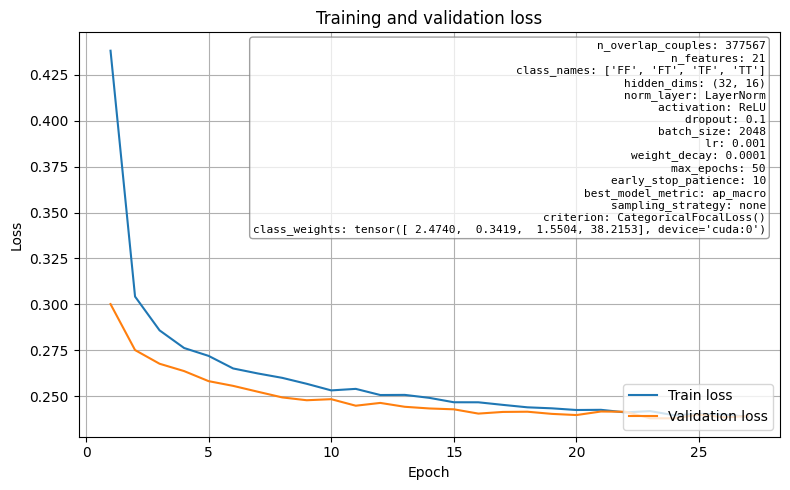

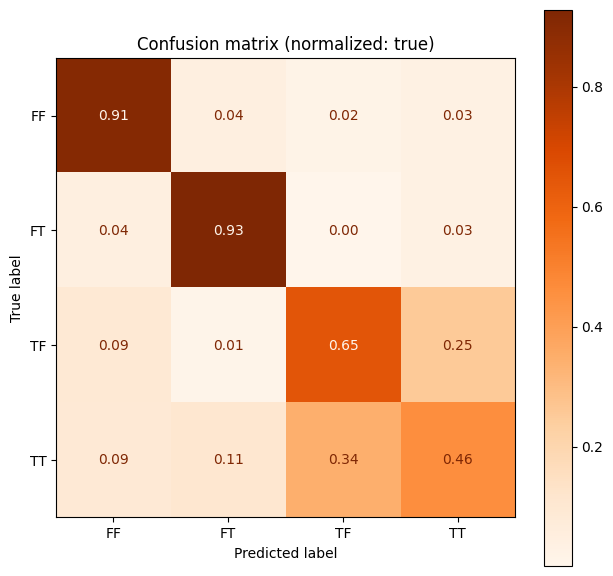

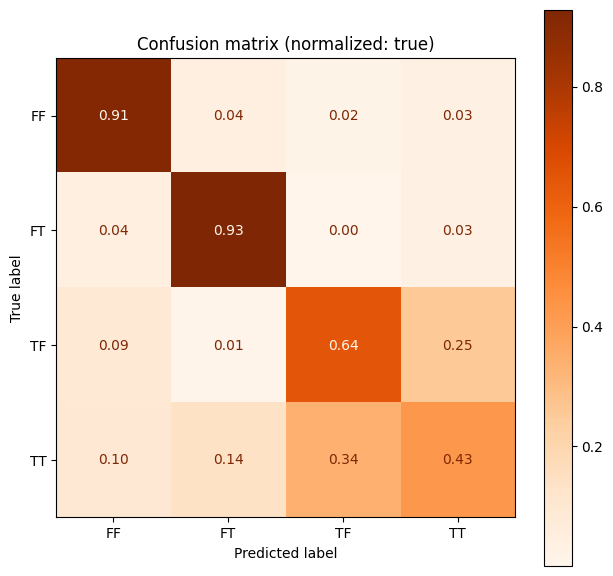

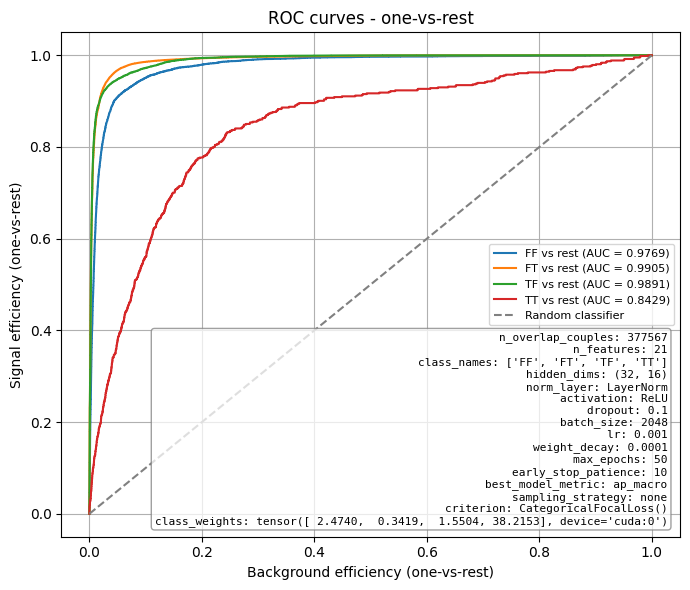

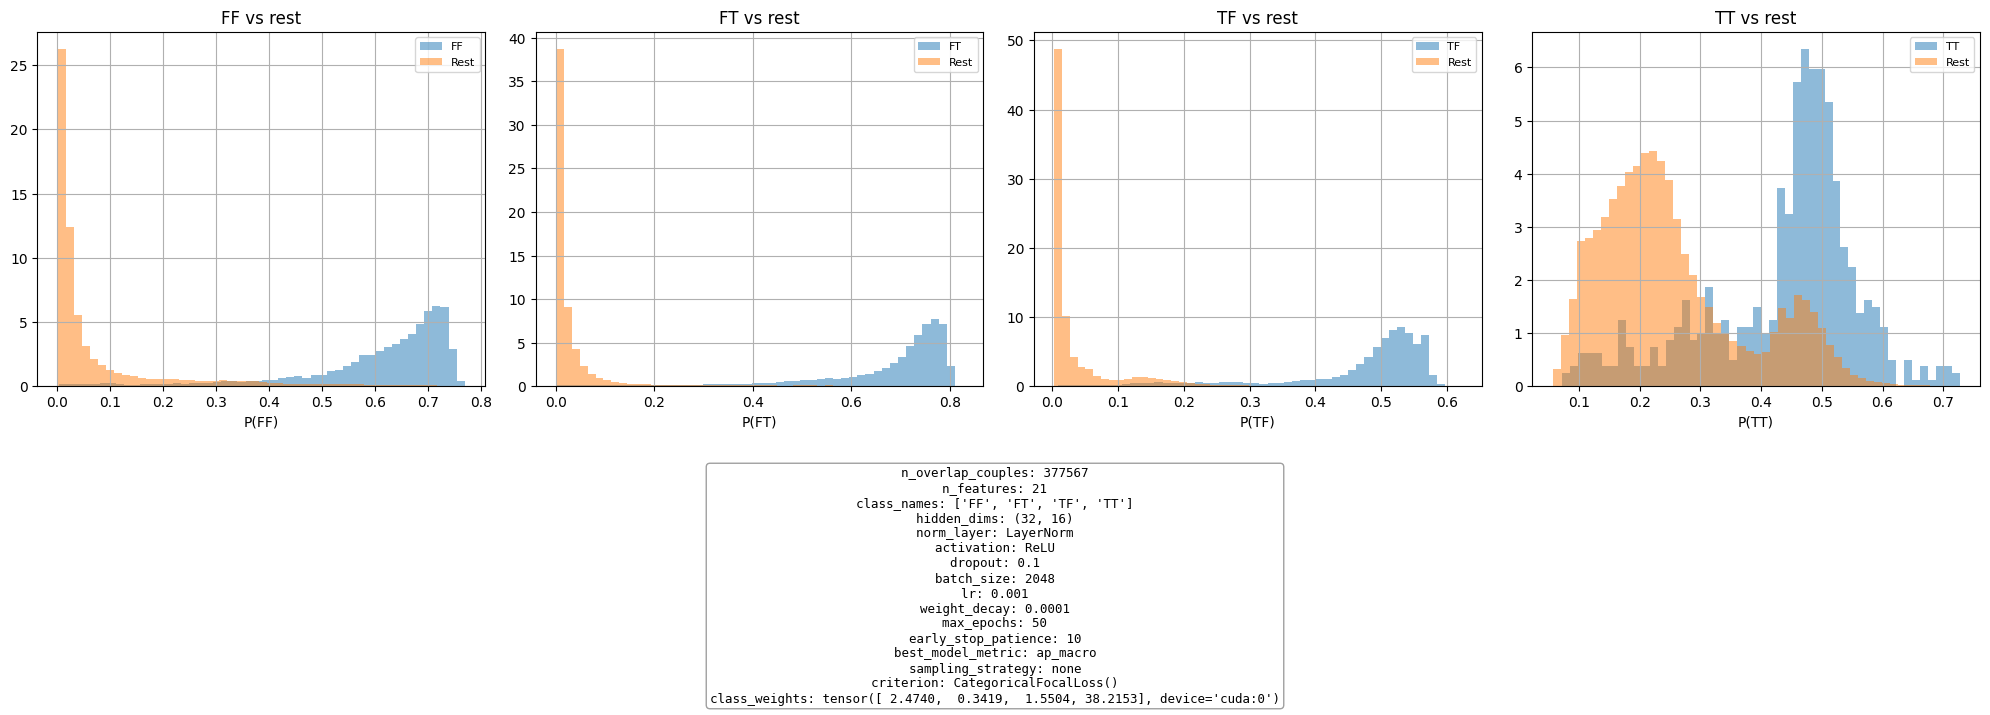

RUN METRICS REPORT - 2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none
run_tag: 2layers_32_16_dropout0.1_LayerNorm_batch2048_lr0.001_wd0.0001_best_on_ap_macro_criterion_CategoricalFocalLoss()_weight_loss_True_sampling_strategy_none
timestamp: 2026-09-23T12:13:39

Dataset
-------
  input_dim: None
  n_train: None | n_val: None | n_test: None
  class balance train (frazione per classe): FF: 0.1010 | FT: 0.7312 | TF: 0.1613 | TT: 0.0065
  class balance test (frazione per classe): FF: 0.1004 | FT: 0.7302 | TF: 0.1619 | TT: 0.0076

Modello
-------
  name: MLPMultiTagger
  hidden_dims: (32, 16)
  num_classes: 4
  norm_layer: <class 'torch.nn.modules.normalization.LayerNorm'>
  dropout: 0.1
  activ_func: ReLU
  n_parametri_totali: 1396
  n_parametri_allenabili: 1396

Training
--------
  criterion: CategoricalFocalLoss
  class_weights: tensor([ 2.4740,  0.3419,  1.5504, 38.2153], device='cuda:

In [ ]:
eval_result = run_evaluation_suite(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    train_losses=train_losses,
    val_losses=val_losses,
    device=DEVICE,
    config=config,
    params=PLOT_PARAMS,
    run_name=RUN_TAG,
    run_tag=RUN_TAG,
    graphics_dir=GRAPHICS_DIR,
    repo_path=REPO_PATH_OVERLAP_RESOLVER,
    output_subdir=GIT_OUTPUT_DIR,
    class_names=CLASS_NAMES,
    working_point_targets=WORKING_POINT_TARGETS,
    atlas_style=ATLAS_STYLE,
    background_rejection_eff_range=BACKGROUND_REJECTION_EFF_RANGE,
    checkpoint_path=CHECKPOINT_PATH,
)

result = eval_result["push_result"]

In [14]:
#################################################################
# FINE-TUNING FOCAL LOSS: SWEEP alpha_power x gamma
#################################################################
from flavour_tag_ml.fine_tuning import sweep_hyperparameters, plot_alpha_gamma_heatmap

ALPHA_POWERS = [0.0, 0.25, 0.5, 0.75, 1.0]
GAMMAS = [0.0, 1.0, 2.0, 3.0, 5.0]

[focal_a0_g0] training in corso...
INFO - Total number of trainable parameters: 1396
INFO - Model selection metric: 'ap_macro'


Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 1/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 1/50 | Train Loss: 0.5316 | Val Loss (mean): 0.2528 | Val F1 (macro): 0.6543 | Val AP (macro): 0.6829


...

Epoch 30/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 30/50 | Train Loss: 0.1725 | Val Loss (mean): 0.1635 | Val F1 (macro): 0.6780 | Val AP (macro): 0.7192


Epoch 31/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 31/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 31/50 | Train Loss: 0.1722 | Val Loss (mean): 0.1632 | Val F1 (macro): 0.6784 | Val AP (macro): 0.7201
Early stopping.
mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


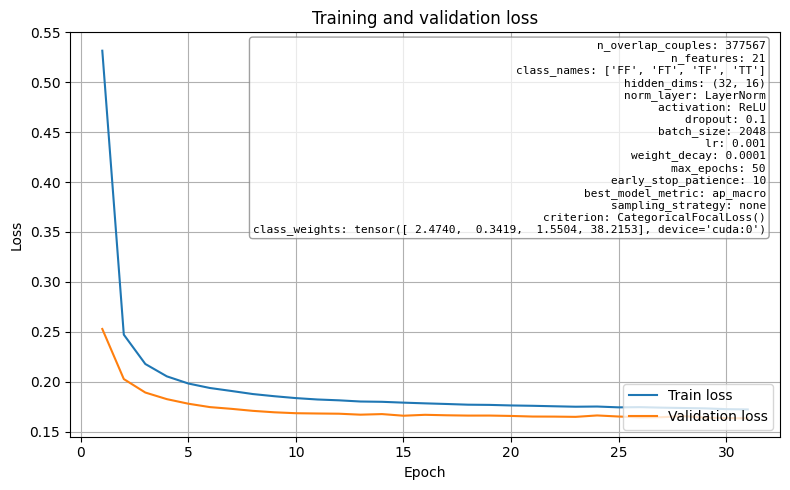

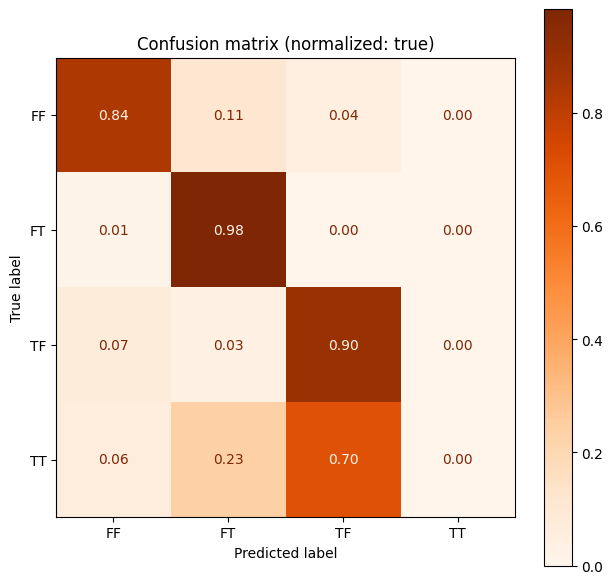

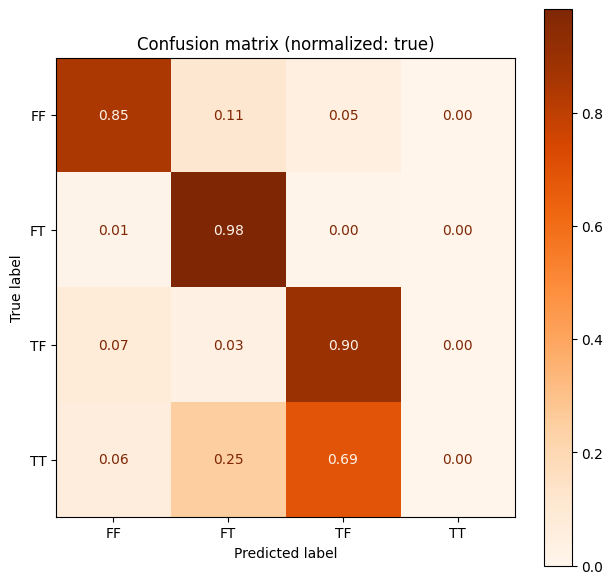

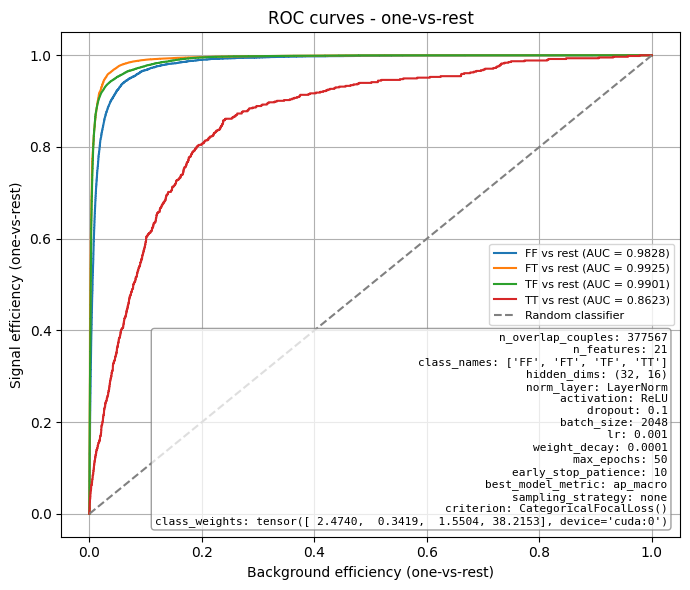

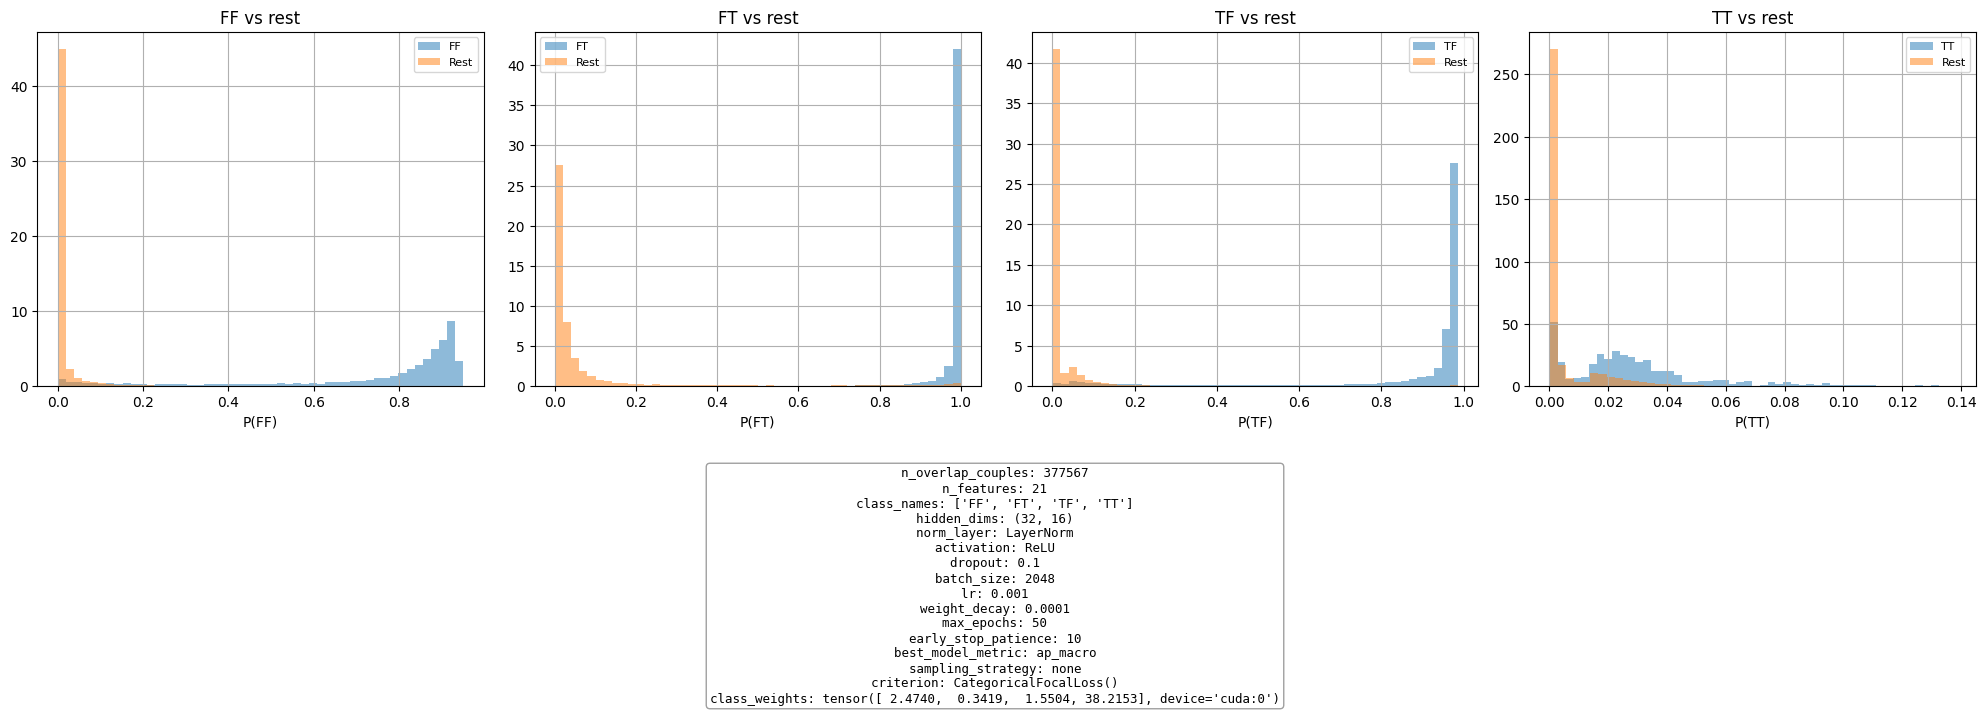

RUN METRICS REPORT - focal_a0_g0
run_tag: focal_a0_g0
timestamp: 2026-09-25T08:44:30

Dataset
-------
  input_dim: None
  n_train: None | n_val: None | n_test: None
  class balance train (frazione per classe): FF: 0.1010 | FT: 0.7312 | TF: 0.1613 | TT: 0.0065
  class balance test (frazione per classe): FF: 0.1004 | FT: 0.7302 | TF: 0.1619 | TT: 0.0076

Modello
-------
  name: MLPMultiTagger
  hidden_dims: (32, 16)
  num_classes: 4
  norm_layer: <class 'torch.nn.modules.normalization.LayerNorm'>
  dropout: 0.1
  activ_func: ReLU
  n_parametri_totali: 1396
  n_parametri_allenabili: 1396

Training
--------
  criterion: CategoricalFocalLoss
  alpha_power: 0.0
  gamma: 0.0
  class_weights_p1: tensor([ 2.4740,  0.3419,  1.5504, 38.2153], device='cuda:0')
  optimizer: {'name': 'AdamW', 'lr': 0.001, 'weight_decay': 0.0001}
  scheduler: {'name': 'ReduceLROnPlateau', 'factor': 0.7, 'patience': 5, 'mode': 'max'}
  max_epochs: 50
  early_stop_patience: 10
  min_delta_val_loss: 0.0001
  model_selec

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 1/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 1/50 | Train Loss: 0.3253 | Val Loss (mean): 0.1499 | Val F1 (macro): 0.6531 | Val AP (macro): 0.6839


...

Epoch 21/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 21/50 | Train Loss: 0.1093 | Val Loss (mean): 0.1028 | Val F1 (macro): 0.6780 | Val AP (macro): 0.7168


Epoch 22/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 22/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 22/50 | Train Loss: 0.1093 | Val Loss (mean): 0.1021 | Val F1 (macro): 0.6771 | Val AP (macro): 0.7160
Early stopping.
mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


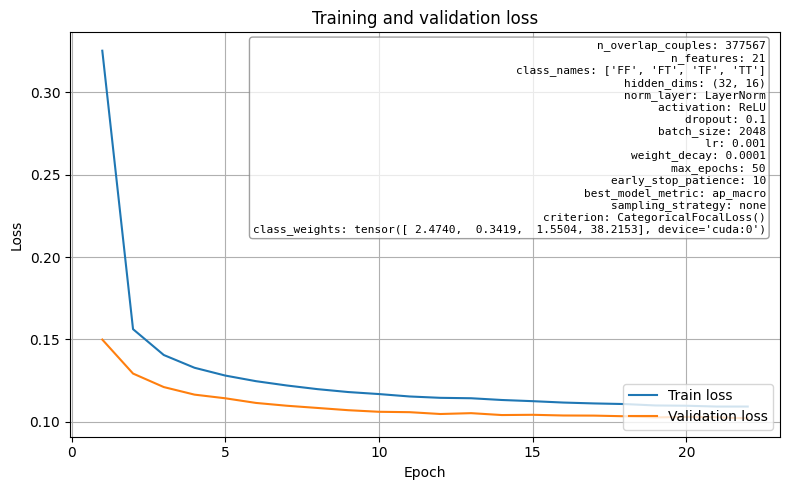

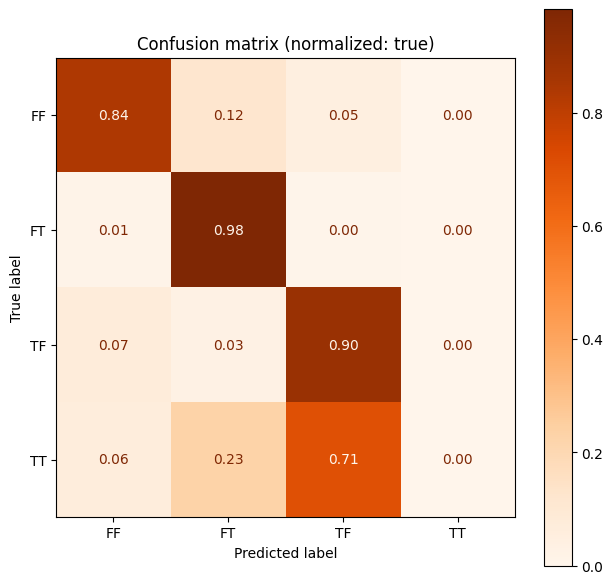

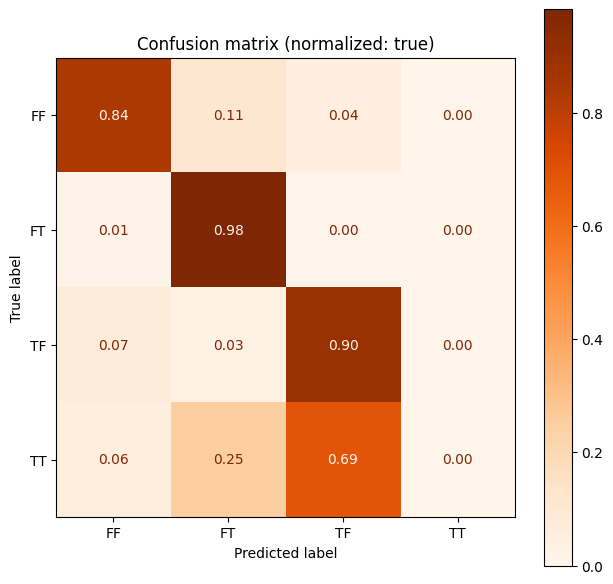

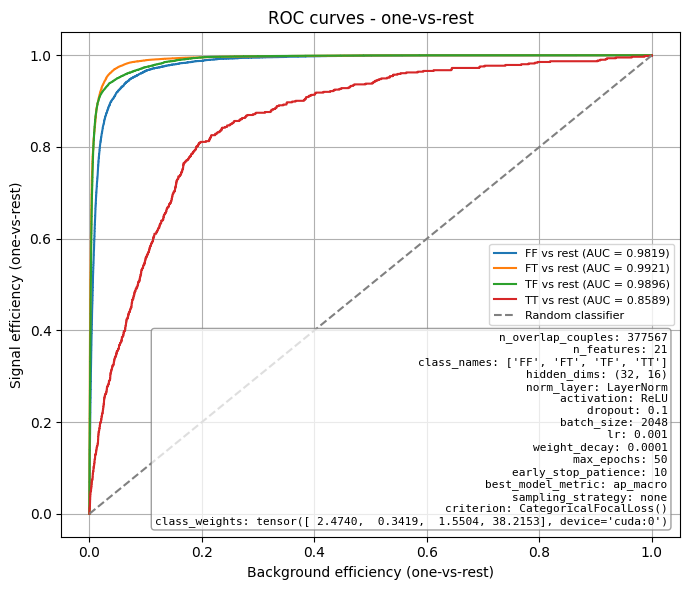

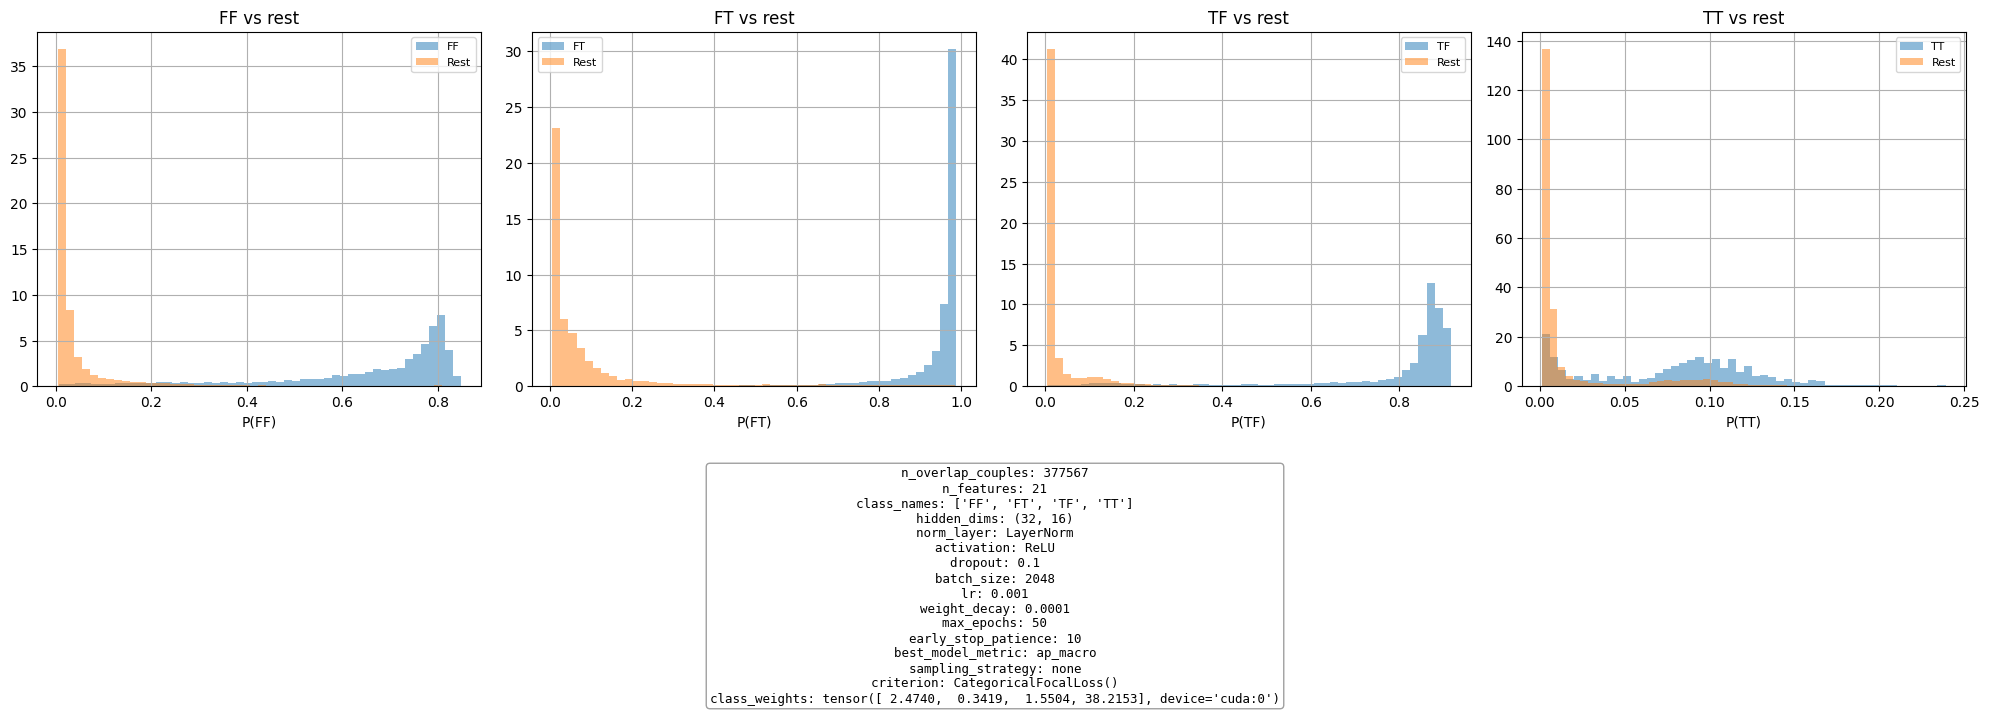

RUN METRICS REPORT - focal_a0_g1
run_tag: focal_a0_g1
timestamp: 2026-09-25T08:47:35

Dataset
-------
  input_dim: None
  n_train: None | n_val: None | n_test: None
  class balance train (frazione per classe): FF: 0.1010 | FT: 0.7312 | TF: 0.1613 | TT: 0.0065
  class balance test (frazione per classe): FF: 0.1004 | FT: 0.7302 | TF: 0.1619 | TT: 0.0076

Modello
-------
  name: MLPMultiTagger
  hidden_dims: (32, 16)
  num_classes: 4
  norm_layer: <class 'torch.nn.modules.normalization.LayerNorm'>
  dropout: 0.1
  activ_func: ReLU
  n_parametri_totali: 1396
  n_parametri_allenabili: 1396

Training
--------
  criterion: CategoricalFocalLoss
  alpha_power: 0.0
  gamma: 1.0
  class_weights_p1: tensor([ 2.4740,  0.3419,  1.5504, 38.2153], device='cuda:0')
  optimizer: {'name': 'AdamW', 'lr': 0.001, 'weight_decay': 0.0001}
  scheduler: {'name': 'ReduceLROnPlateau', 'factor': 0.7, 'patience': 5, 'mode': 'max'}
  max_epochs: 50
  early_stop_patience: 10
  min_delta_val_loss: 0.0001
  model_selec

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 1/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 1/50 | Train Loss: 0.2193 | Val Loss (mean): 0.1027 | Val F1 (macro): 0.6518 | Val AP (macro): 0.6820


...

Epoch 46/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 46/50 | Train Loss: 0.0703 | Val Loss (mean): 0.0674 | Val F1 (macro): 0.6801 | Val AP (macro): 0.7168


Epoch 47/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 47/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 47/50 | Train Loss: 0.0703 | Val Loss (mean): 0.0676 | Val F1 (macro): 0.6803 | Val AP (macro): 0.7164
Early stopping.
mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


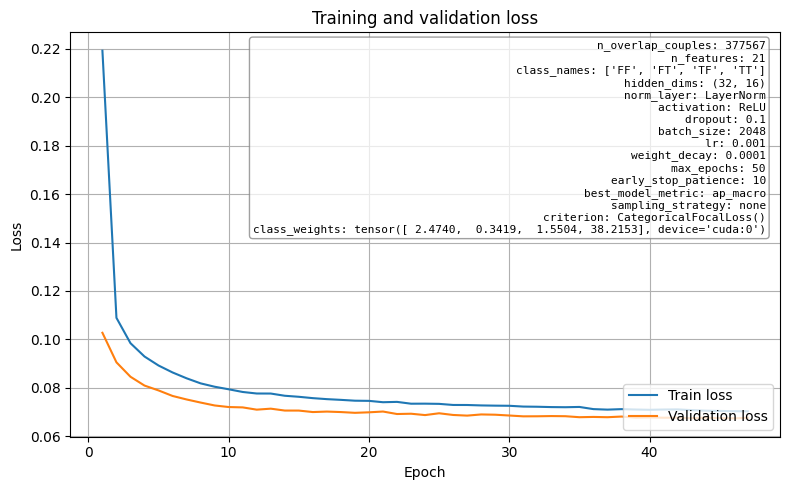

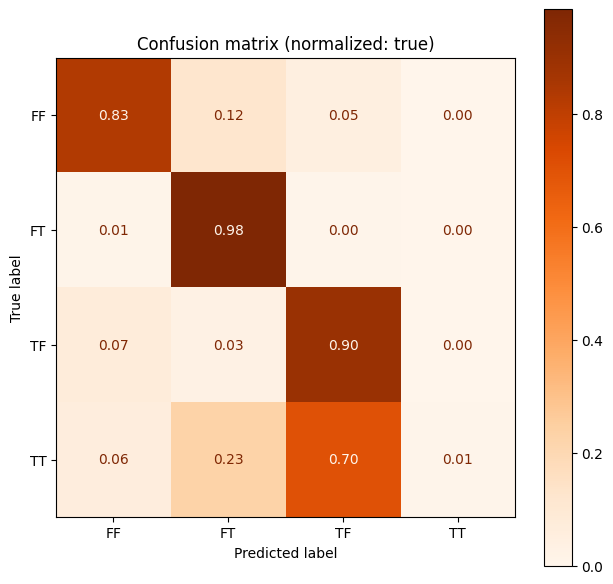

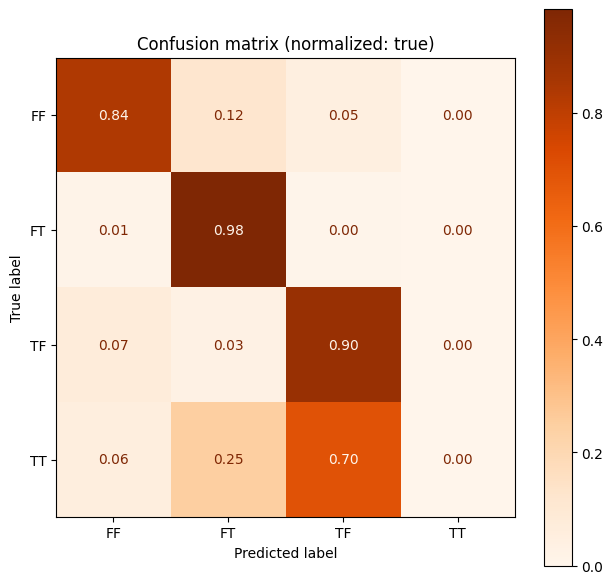

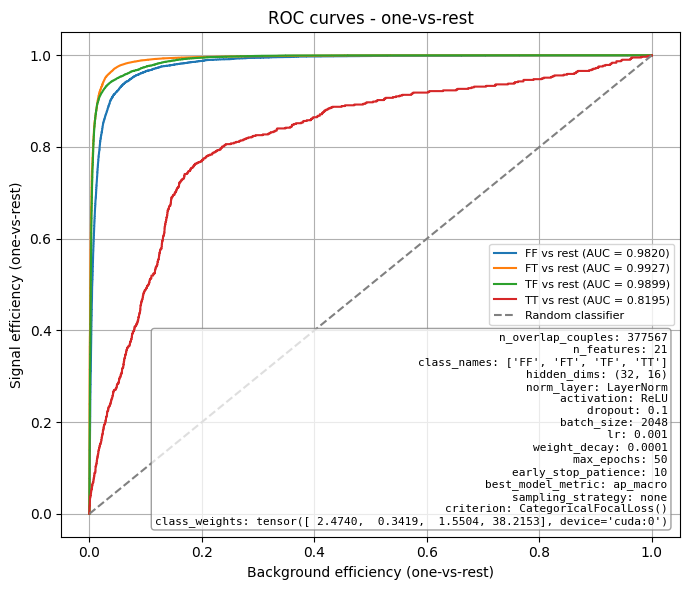

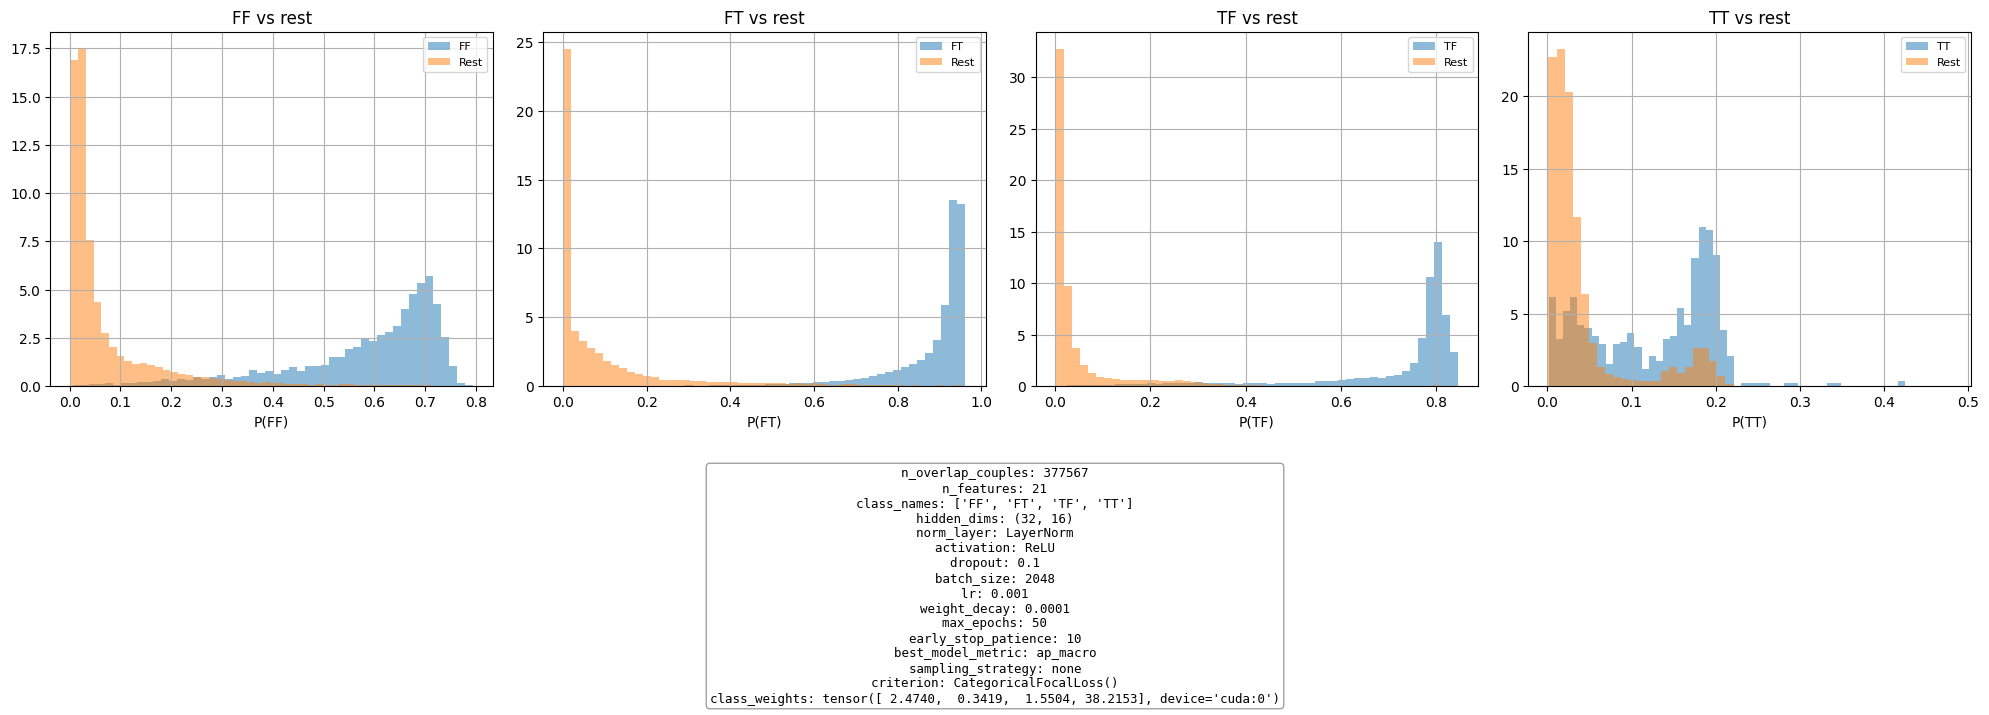

RUN METRICS REPORT - focal_a0_g2
run_tag: focal_a0_g2
timestamp: 2026-09-25T08:55:21

Dataset
-------
  input_dim: None
  n_train: None | n_val: None | n_test: None
  class balance train (frazione per classe): FF: 0.1011 | FT: 0.7311 | TF: 0.1613 | TT: 0.0066
  class balance test (frazione per classe): FF: 0.1004 | FT: 0.7302 | TF: 0.1619 | TT: 0.0076

Modello
-------
  name: MLPMultiTagger
  hidden_dims: (32, 16)
  num_classes: 4
  norm_layer: <class 'torch.nn.modules.normalization.LayerNorm'>
  dropout: 0.1
  activ_func: ReLU
  n_parametri_totali: 1396
  n_parametri_allenabili: 1396

Training
--------
  criterion: CategoricalFocalLoss
  alpha_power: 0.0
  gamma: 2.0
  class_weights_p1: tensor([ 2.4740,  0.3419,  1.5504, 38.2153], device='cuda:0')
  optimizer: {'name': 'AdamW', 'lr': 0.001, 'weight_decay': 0.0001}
  scheduler: {'name': 'ReduceLROnPlateau', 'factor': 0.7, 'patience': 5, 'mode': 'max'}
  max_epochs: 50
  early_stop_patience: 10
  min_delta_val_loss: 0.0001
  model_selec

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 1/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 1/50 | Train Loss: 0.1543 | Val Loss (mean): 0.0735 | Val F1 (macro): 0.6506 | Val AP (macro): 0.6799


...

Epoch 24/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 24/50 | Train Loss: 0.0513 | Val Loss (mean): 0.0477 | Val F1 (macro): 0.6775 | Val AP (macro): 0.7133


Epoch 25/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 25/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 25/50 | Train Loss: 0.0513 | Val Loss (mean): 0.0481 | Val F1 (macro): 0.6772 | Val AP (macro): 0.7131
Early stopping.
mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


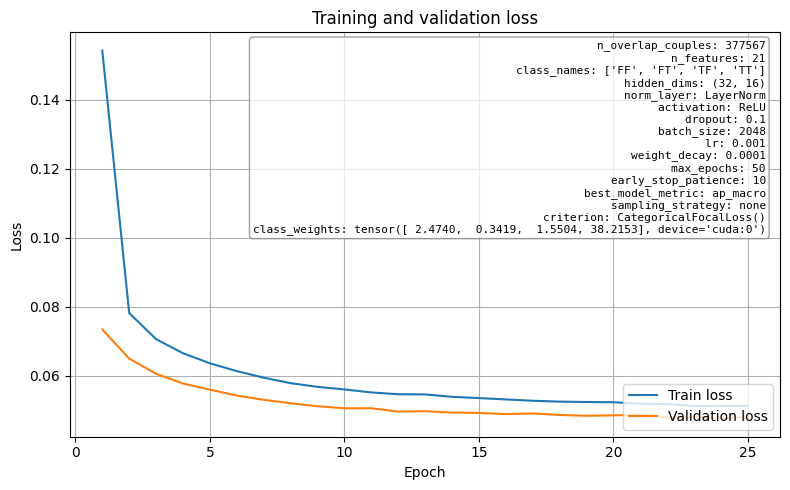

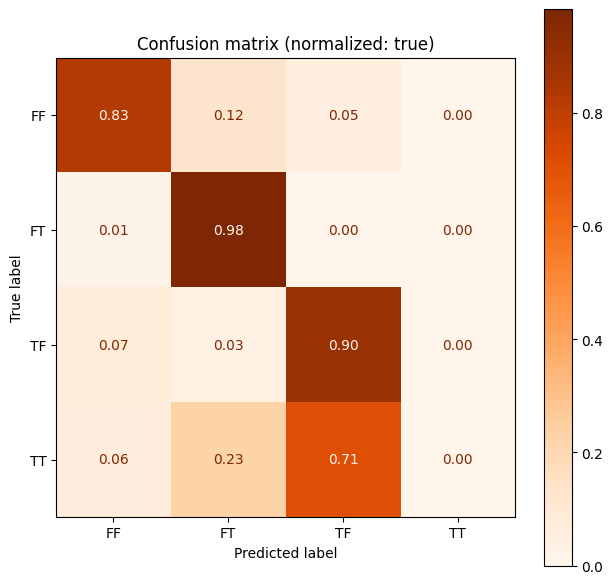

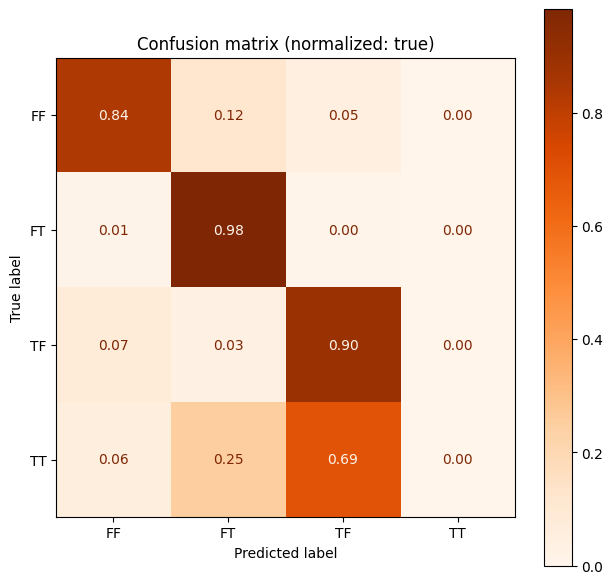

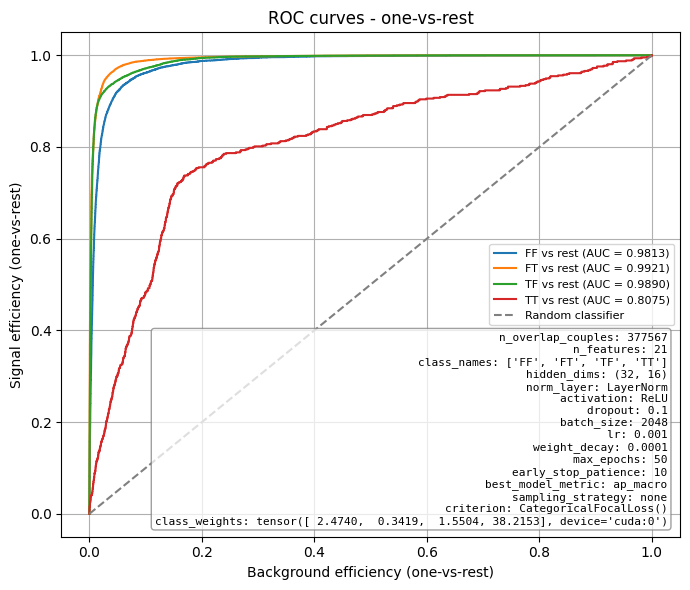

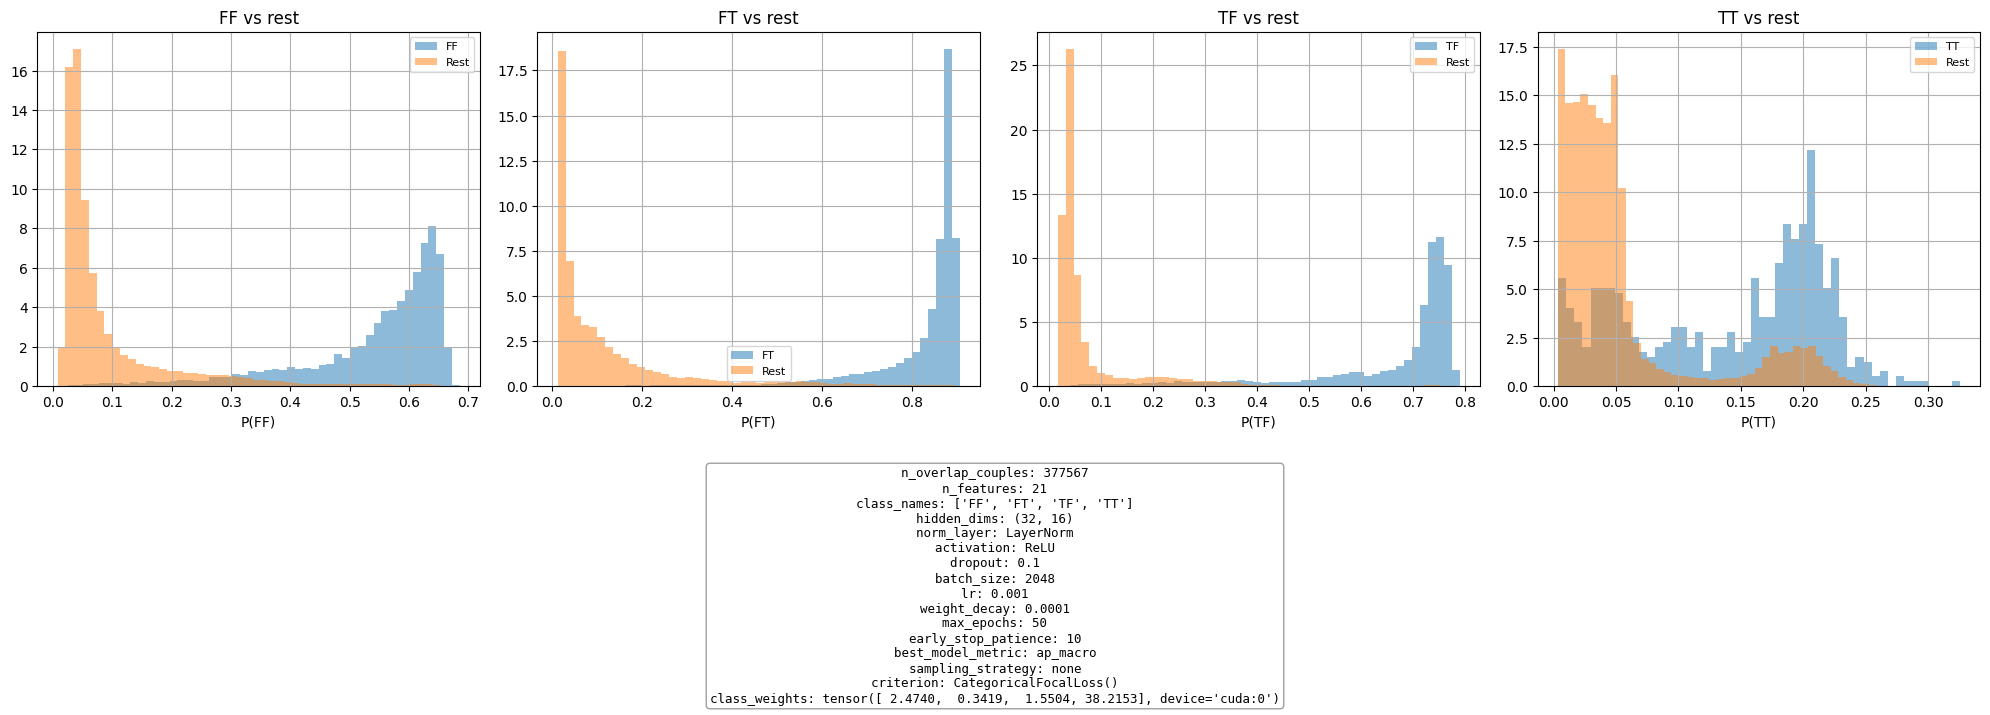

RUN METRICS REPORT - focal_a0_g3
run_tag: focal_a0_g3
timestamp: 2026-09-25T08:59:55

Dataset
-------
  input_dim: None
  n_train: None | n_val: None | n_test: None
  class balance train (frazione per classe): FF: 0.1010 | FT: 0.7311 | TF: 0.1613 | TT: 0.0065
  class balance test (frazione per classe): FF: 0.1004 | FT: 0.7302 | TF: 0.1619 | TT: 0.0076

Modello
-------
  name: MLPMultiTagger
  hidden_dims: (32, 16)
  num_classes: 4
  norm_layer: <class 'torch.nn.modules.normalization.LayerNorm'>
  dropout: 0.1
  activ_func: ReLU
  n_parametri_totali: 1396
  n_parametri_allenabili: 1396

Training
--------
  criterion: CategoricalFocalLoss
  alpha_power: 0.0
  gamma: 3.0
  class_weights_p1: tensor([ 2.4740,  0.3419,  1.5504, 38.2153], device='cuda:0')
  optimizer: {'name': 'AdamW', 'lr': 0.001, 'weight_decay': 0.0001}
  scheduler: {'name': 'ReduceLROnPlateau', 'factor': 0.7, 'patience': 5, 'mode': 'max'}
  max_epochs: 50
  early_stop_patience: 10
  min_delta_val_loss: 0.0001
  model_selec

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 1/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 1/50 | Train Loss: 0.0817 | Val Loss (mean): 0.0397 | Val F1 (macro): 0.6490 | Val AP (macro): 0.6776


...

Epoch 24/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 24/50 | Train Loss: 0.0266 | Val Loss (mean): 0.0246 | Val F1 (macro): 0.6766 | Val AP (macro): 0.7079


Epoch 25/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 25/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 25/50 | Train Loss: 0.0266 | Val Loss (mean): 0.0250 | Val F1 (macro): 0.6768 | Val AP (macro): 0.7095
Early stopping.
mplhep non installato - stile ATLAS non applicato (pip install mplhep per abilitarlo). I plot funzionano comunque con lo stile matplotlib di default.


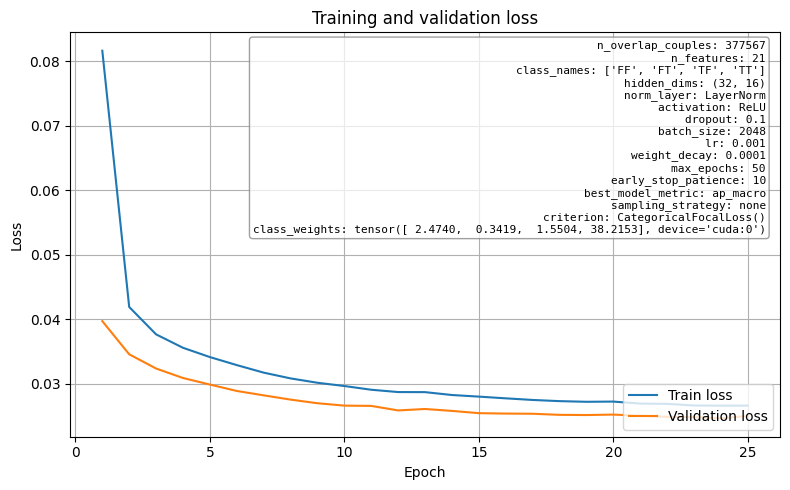

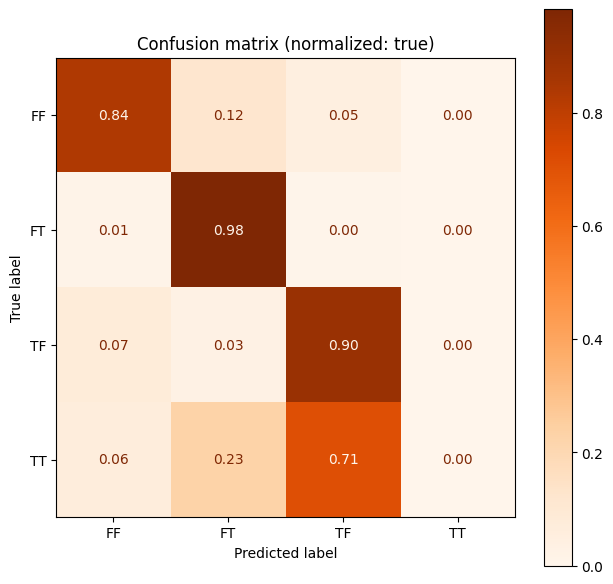

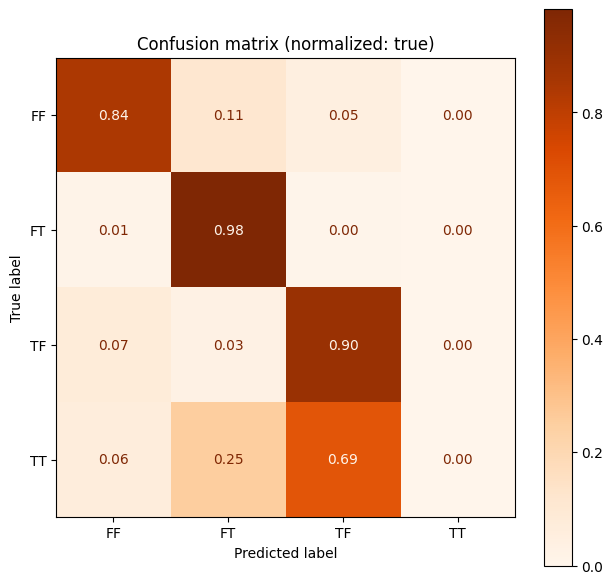

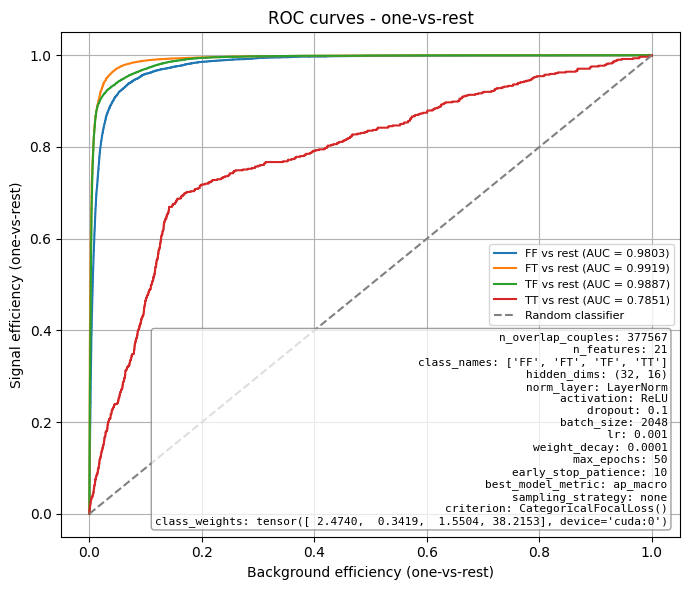

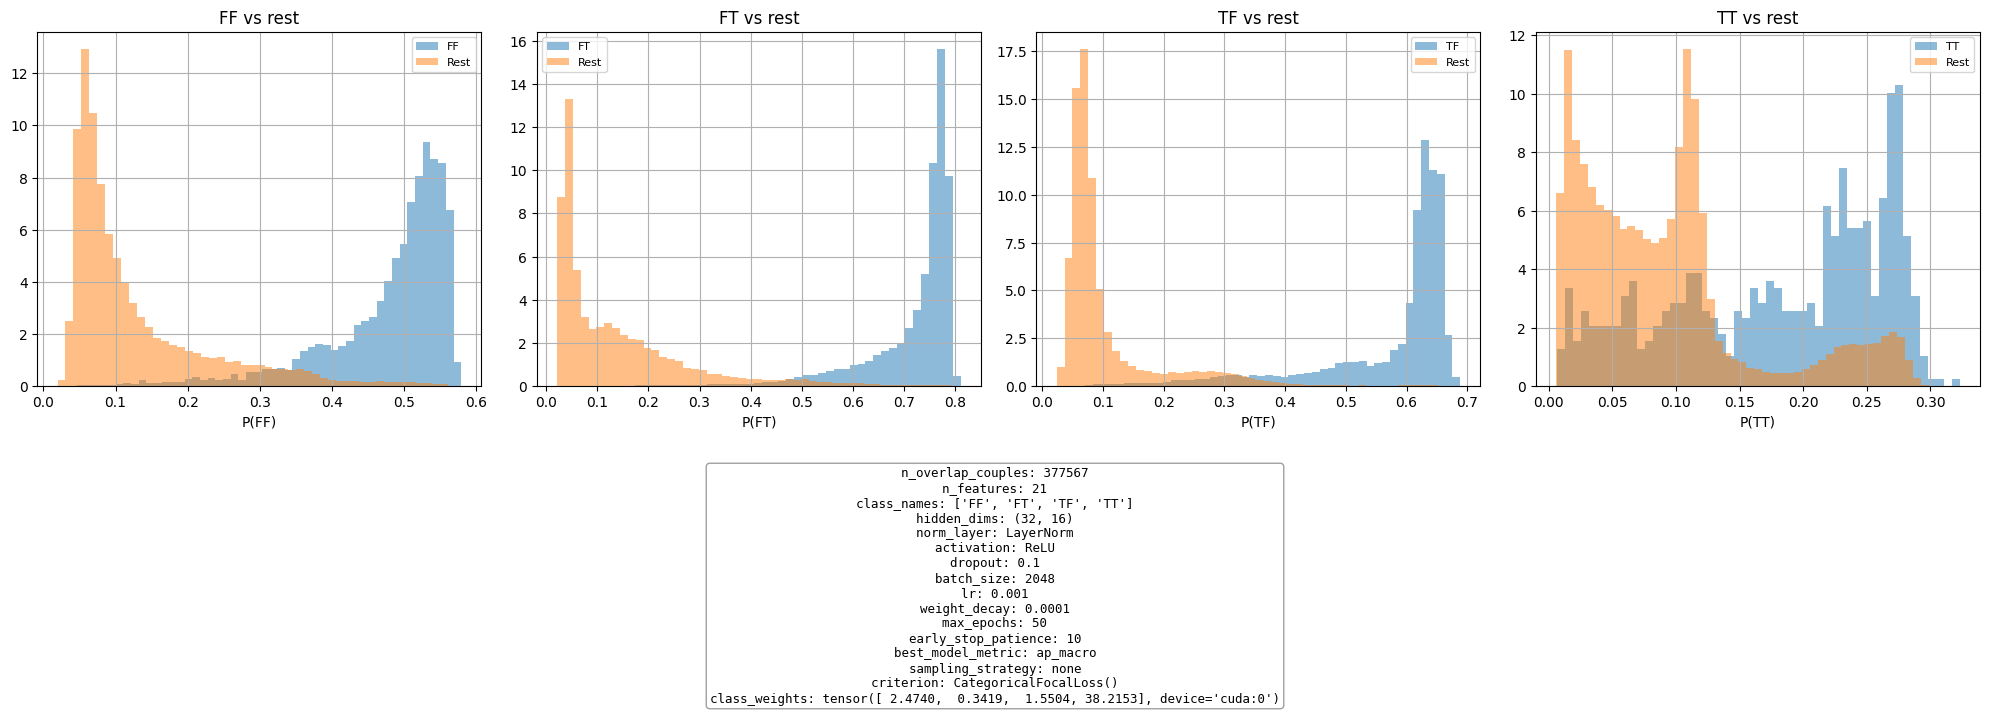

RUN METRICS REPORT - focal_a0_g5
run_tag: focal_a0_g5
timestamp: 2026-09-25T09:04:23

Dataset
-------
  input_dim: None
  n_train: None | n_val: None | n_test: None
  class balance train (frazione per classe): FF: 0.1010 | FT: 0.7311 | TF: 0.1613 | TT: 0.0065
  class balance test (frazione per classe): FF: 0.1004 | FT: 0.7302 | TF: 0.1619 | TT: 0.0076

Modello
-------
  name: MLPMultiTagger
  hidden_dims: (32, 16)
  num_classes: 4
  norm_layer: <class 'torch.nn.modules.normalization.LayerNorm'>
  dropout: 0.1
  activ_func: ReLU
  n_parametri_totali: 1396
  n_parametri_allenabili: 1396

Training
--------
  criterion: CategoricalFocalLoss
  alpha_power: 0.0
  gamma: 5.0
  class_weights_p1: tensor([ 2.4740,  0.3419,  1.5504, 38.2153], device='cuda:0')
  optimizer: {'name': 'AdamW', 'lr': 0.001, 'weight_decay': 0.0001}
  scheduler: {'name': 'ReduceLROnPlateau', 'factor': 0.7, 'patience': 5, 'mode': 'max'}
  max_epochs: 50
  early_stop_patience: 10
  min_delta_val_loss: 0.0001
  model_selec

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 1/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 1/50 | Train Loss: 0.5245 | Val Loss (mean): 0.2808 | Val F1 (macro): 0.6550 | Val AP (macro): 0.6866


...

Epoch 10/50 | Train Loss: 0.2257 | Val Loss (mean): 0.2108 | Val F1 (macro): 0.6759 | Val AP (macro): 0.7182


Epoch 11/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

Epoch 11/50 [val]:   0%|          | 0/40 [00:00<?, ?batch/s]

Epoch 11/50 | Train Loss: 0.2235 | Val Loss (mean): 0.2099 | Val F1 (macro): 0.6772 | Val AP (macro): 0.7190


Epoch 12/50 [train]:   0%|          | 0/184 [00:00<?, ?batch/s]

In [ ]:

# base_config: solo "data"/"model" (la chiave "training" la costruisce
# sweep_hyperparameters per ogni combo, con alpha_power/gamma/metriche
# incluse esplicitamente - vedi scan_existing_runs).
base_config = {
    "data": config["data"],
    "model": config["model"],
}

results_df = sweep_hyperparameters(
    alpha_powers=ALPHA_POWERS,
    gammas=GAMMAS,
    base_class_weights=CLASS_WEIGHTS,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_factory=lambda: create_model(MODEL_CONFIG, input_dim=X_train.shape[1]),
    optimizer_config=OPTIMIZER_CONFIG,
    scheduler_config=SCHEDULER_CONFIG,
    max_epochs=MAX_EPOCHS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    min_delta_val_loss=MIN_DELTA_VAL_LOSS,
    device=DEVICE,
    class_names=CLASS_NAMES,
    graphics_dir=GRAPHICS_DIR,
    repo_path=REPO_PATH_OVERLAP_RESOLVER,
    output_subdir=GIT_OUTPUT_DIR,
    base_config=base_config,
    params=PLOT_PARAMS,
    checkpoint_dir=MODEL_DIR,
    working_point_targets=WORKING_POINT_TARGETS,
    atlas_style=ATLAS_STYLE,
    seed=RANDOM_SEED,  # stesso seed per ogni combo - vedi docstring di
                        # train_one_combo per il perche' (isola l'effetto
                        # di alpha/gamma dal rumore di init/ordine dati
                        # dovuto alla condivisione di train_loader/val_loader
                        # tra le combo dello sweep).
)

plot_alpha_gamma_heatmap(results_df, metric="val_ap_macro")
plot_alpha_gamma_heatmap(results_df, metric="val_ap_TT")
